In [17]:
# ==========================================
# CELL 1 — IMPORT LIBRARIES
# ==========================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import xgboost as xgb
from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style="whitegrid")

In [18]:
# ==========================================
# CELL 2 — LOAD UPDATED DATASET
# ==========================================

DATA_PATH = "/content/drive/MyDrive/MalnutritionProject/final_project_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df_raw.shape)
print("Total Rows:", len(df_raw))
print("\nColumns:\n", df_raw.columns.tolist())

df_raw.head()

Dataset Shape: (200602, 17)
Total Rows: 200602

Columns:
 ['Age_Months', 'Weight_kg', 'Height_cm', 'Hemoglobin_gdl', 'Sex', 'Mother_Education', 'Water_Source', 'Toilet_Facility', 'Wealth_Index', 'Household_Size', 'Birth_Weight', 'MUAC', 'HAZ_Zscore', 'WHZ_Zscore', 'WAZ_Zscore', 'BAZ_Zscore', 'Risk_Level']


,Age_Months,Weight_kg,Height_cm,Hemoglobin_gdl,Sex,Mother_Education,Water_Source,Toilet_Facility,Wealth_Index,Household_Size,Birth_Weight,MUAC,HAZ_Zscore,WHZ_Zscore,WAZ_Zscore,BAZ_Zscore,Risk_Level
0,49,15.5,100.2,11.2,0,2,2,2,2,4,2700,9.281,-0.78,0.16,-0.38,0.13,Normal
1,29,10.1,83.9,11.8,0,2,2,2,2,3,2800,7.223,-1.72,-1.10,-1.76,-0.98,Low
2,30,12.0,84.6,12.6,1,2,2,2,1,6,3000,8.511,-2.23,0.45,-0.92,0.77,Medium
3,7,7.9,67.9,12.1,1,2,2,2,2,6,2500,6.981,-0.78,-0.07,-0.56,-0.13,Normal
4,27,12.1,84.6,9.6,0,2,0,2,1,5,2800,8.582,-1.05,0.72,-0.01,0.88,Low


In [19]:
# ==========================================
# CELL 3 — CLEANING & BASE LOCK
# ==========================================

df = df_raw.copy()

print("Missing Values:\n")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")

BASE_COUNT = len(df)

print("\n🔒 LOCKED BASE COUNT:", BASE_COUNT)

Missing Values:

Age_Months          0
Weight_kg           0
Height_cm           0
Hemoglobin_gdl      0
Sex                 0
Mother_Education    0
Water_Source        0
Toilet_Facility     0
Wealth_Index        0
Household_Size      0
Birth_Weight        0
MUAC                0
HAZ_Zscore          0
WHZ_Zscore          0
WAZ_Zscore          0
BAZ_Zscore          0
Risk_Level          0
dtype: int64

Duplicate Rows: 0
No duplicates found.

🔒 LOCKED BASE COUNT: 200602



🔎 Sex Unique Values:
Sex
1    103944
0     96658
Name: count, dtype: int64


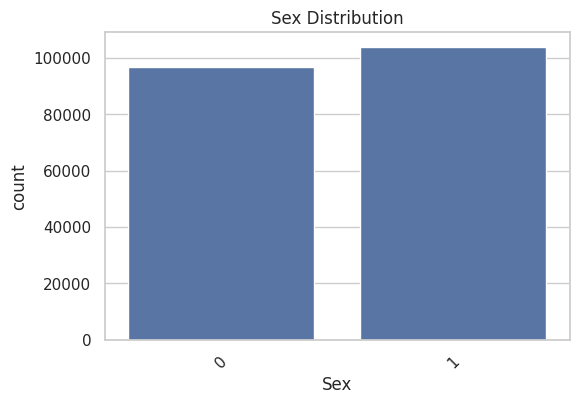


🔎 Mother_Education Unique Values:
Mother_Education
2    108572
0     62588
1     29442
Name: count, dtype: int64


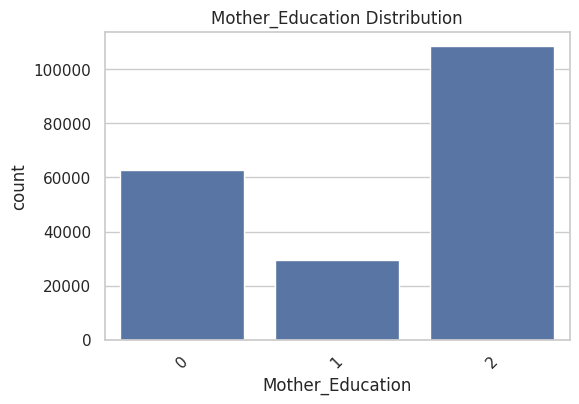


🔎 Water_Source Unique Values:
Water_Source
0    103456
2     74535
1     22611
Name: count, dtype: int64


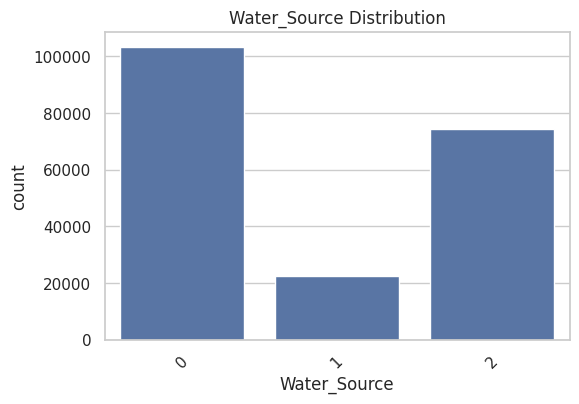


🔎 Toilet_Facility Unique Values:
Toilet_Facility
0    114109
2     67171
1     19322
Name: count, dtype: int64


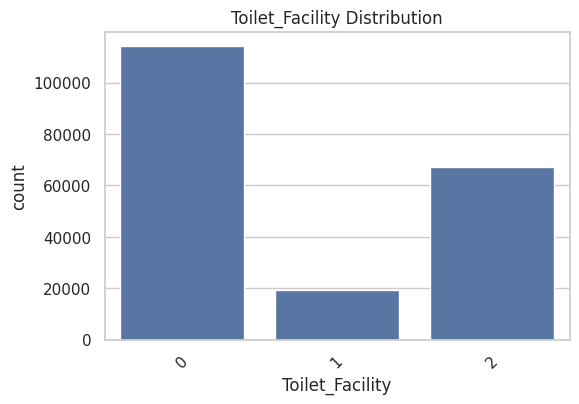


🔎 Wealth_Index Unique Values:
Wealth_Index
0    99635
2    60696
1    40271
Name: count, dtype: int64


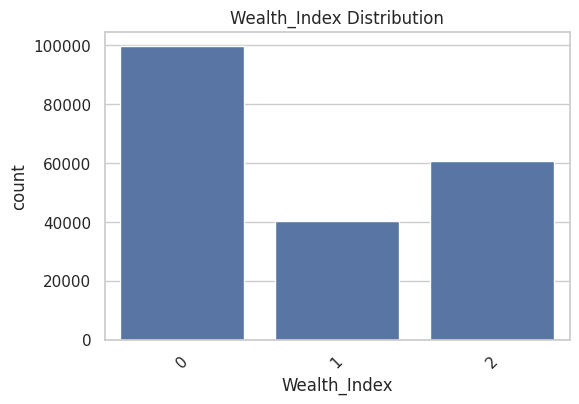


🔎 Risk_Level Unique Values:
Risk_Level
Medium    61689
Low       58845
High      50695
Normal    29373
Name: count, dtype: int64


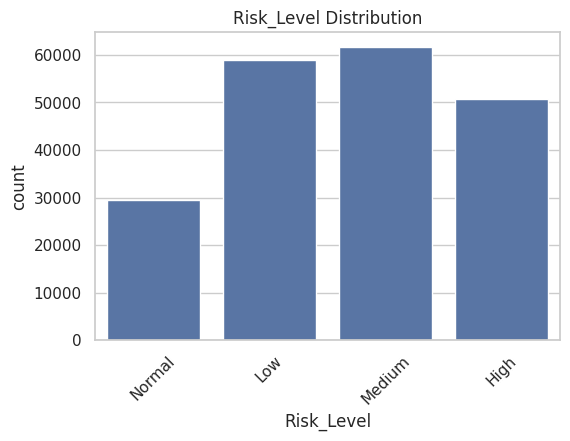

In [20]:
# ==========================================
# CELL 4 — CATEGORICAL DIVERSITY CHECK
# ==========================================

categorical_cols = [
    "Sex",
    "Mother_Education",
    "Water_Source",
    "Toilet_Facility",
    "Wealth_Index",
    "Risk_Level"
]

for col in categorical_cols:
    print(f"\n🔎 {col} Unique Values:")
    print(df[col].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [21]:
# ==========================================
# CELL 5 — NUMERIC SUMMARY & RANGE CHECK
# ==========================================

numeric_cols = [
    "Age_Months",
    "Weight_kg",
    "Height_cm",
    "Hemoglobin_gdl",
    "Household_Size",
    "Birth_Weight",
    "MUAC",
    "HAZ_Zscore",
    "WHZ_Zscore",
    "WAZ_Zscore",
    "BAZ_Zscore"
]

summary = df[numeric_cols].describe().T
print(summary)

                   count         mean          std      min       25%  \
Age_Months      200602.0    32.796328    15.424659    6.000    19.000   
Weight_kg       200602.0    11.115590     2.772015    3.500     9.000   
Height_cm       200602.0    86.132439    11.392429   52.400    77.300   
Hemoglobin_gdl  200602.0    10.592990     1.536387    1.000     9.700   
Household_Size  200602.0     6.528160     2.851682    2.000     5.000   
Birth_Weight    200602.0  4596.333013  3135.162177  500.000  2500.000   
MUAC            200602.0     7.649782     1.121734    3.711     6.888   
HAZ_Zscore      200602.0    -1.577812     1.623640   -6.000    -2.600   
WHZ_Zscore      200602.0    -0.963485     1.338422   -5.000    -1.760   
WAZ_Zscore      200602.0    -1.560824     1.198366   -5.940    -2.350   
BAZ_Zscore      200602.0    -0.802884     1.408420   -5.000    -1.610   

                     50%       75%       max  
Age_Months        33.000    46.000    59.000  
Weight_kg         11.000    1

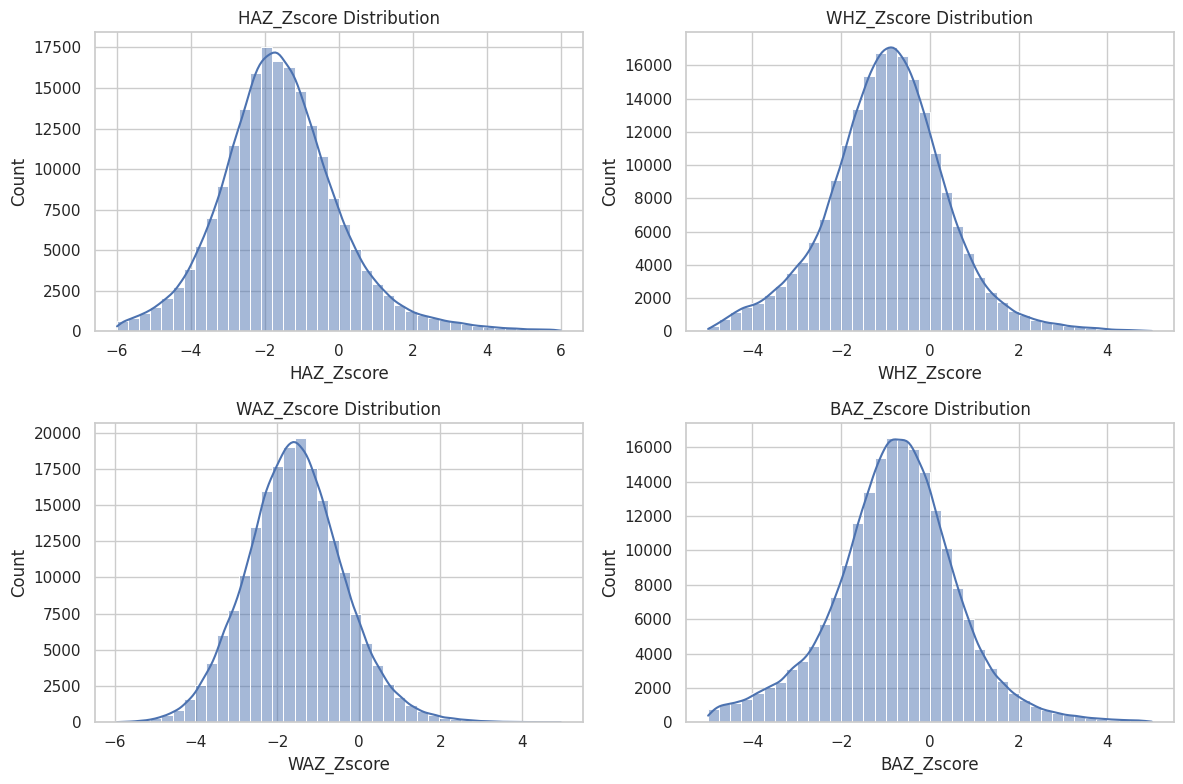

In [22]:
# ==========================================
# CELL 6 — Z-SCORE DISTRIBUTION PLOTS
# ==========================================

z_cols = ["HAZ_Zscore", "WHZ_Zscore", "WAZ_Zscore", "BAZ_Zscore"]

plt.figure(figsize=(12,8))

for i, col in enumerate(z_cols):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

Cell 7

Risk Level Distribution:

            Count  Percentage (%)
Risk_Level                       
High        50695           25.27
Low         58845           29.33
Medium      61689           30.75
Normal      29373           14.64


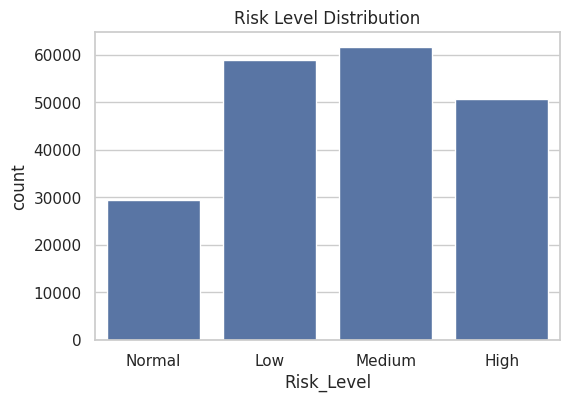

In [25]:
# ==========================================
# CELL 8 — CLASS DISTRIBUTION CHECK
# ==========================================

class_counts = df["Risk_Level"].value_counts().sort_index()
class_percent = (class_counts / len(df)) * 100

distribution_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percent.round(2)
})

print("Risk Level Distribution:\n")
print(distribution_df)

plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Level", data=df)
plt.title("Risk Level Distribution")
plt.show()

In [26]:
# ==========================================
# CELL 9 — DOWNSAMPLING TO NORMAL COUNT
# ==========================================

min_class_count = df["Risk_Level"].value_counts().min()

print("Minimum class count (Normal):", min_class_count)

balanced_dfs = []

for risk in df["Risk_Level"].unique():
    subset = df[df["Risk_Level"] == risk]
    sampled = subset.sample(min_class_count, random_state=42)
    balanced_dfs.append(sampled)

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)

BASE_COUNT_BALANCED = len(df_balanced)

print("\nBalanced Dataset Shape:", df_balanced.shape)
print("🔒 LOCKED BALANCED BASE COUNT:", BASE_COUNT_BALANCED)

Minimum class count (Normal): 29373

Balanced Dataset Shape: (117492, 17)
🔒 LOCKED BALANCED BASE COUNT: 117492


Balanced Distribution:

            Count  Percentage (%)
Risk_Level                       
High        29373            25.0
Low         29373            25.0
Medium      29373            25.0
Normal      29373            25.0


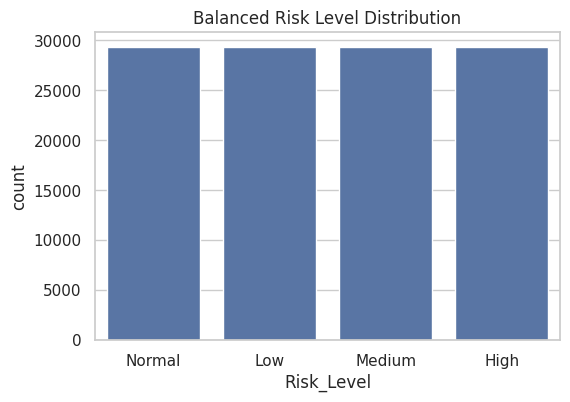

In [27]:
# ==========================================
# CELL 10 — VERIFY BALANCED DISTRIBUTION
# ==========================================

balanced_counts = df_balanced["Risk_Level"].value_counts().sort_index()
balanced_percent = (balanced_counts / BASE_COUNT_BALANCED) * 100

balanced_distribution_df = pd.DataFrame({
    "Count": balanced_counts,
    "Percentage (%)": balanced_percent.round(2)
})

print("Balanced Distribution:\n")
print(balanced_distribution_df)

plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Level", data=df_balanced)
plt.title("Balanced Risk Level Distribution")
plt.show()

In [28]:
# ==========================================
# CELL 11 — LABEL ENCODING
# ==========================================

from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = [
    "Sex",
    "Mother_Education",
    "Water_Source",
    "Toilet_Facility",
    "Wealth_Index",
    "Risk_Level"
]

for col in categorical_cols:
    le = LabelEncoder()
    df_balanced[col] = le.fit_transform(df_balanced[col])
    encoders[col] = le

# Create label map (for app compatibility)
label_map = {int(i): label for i, label in enumerate(encoders["Risk_Level"].classes_)}

print("Label Map:", label_map)

# Verify unique encoded classes
print("\nEncoded Risk_Level unique values:")
print(df_balanced["Risk_Level"].unique())

Label Map: {0: 'High', 1: 'Low', 2: 'Medium', 3: 'Normal'}

Encoded Risk_Level unique values:
[3 1 2 0]


In [29]:
# ==========================================
# CELL 12 — FINAL FEATURE LOCK
# ==========================================

FEATURES = [
    "Age_Months",
    "Weight_kg",
    "Height_cm",
    "Hemoglobin_gdl",
    "Sex",
    "Mother_Education",
    "Water_Source",
    "Toilet_Facility",
    "Wealth_Index",
    "Household_Size",
    "Birth_Weight",
    "MUAC",
    "HAZ_Zscore",
    "WHZ_Zscore",
    "WAZ_Zscore",
    "BAZ_Zscore"
]

TARGET = "Risk_Level"

X = df_balanced[FEATURES].copy()
y = df_balanced[TARGET].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(FEATURES))

Feature matrix shape: (117492, 16)
Target shape: (117492,)
Number of features: 16


In [30]:
# ==========================================
# CELL 13 — TRAIN / TEST SPLIT (STRATIFIED)
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTrain %:", round(len(X_train)/len(X)*100, 2))
print("Test %:", round(len(X_test)/len(X)*100, 2))

Train Shape: (93993, 16)
Test Shape: (23499, 16)

Train %: 80.0
Test %: 20.0


Train Distribution:
 Risk_Level
1    25.000798
2    24.999734
3    24.999734
0    24.999734
Name: proportion, dtype: float64

Test Distribution:
 Risk_Level
0    25.001064
2    25.001064
3    25.001064
1    24.996808
Name: proportion, dtype: float64


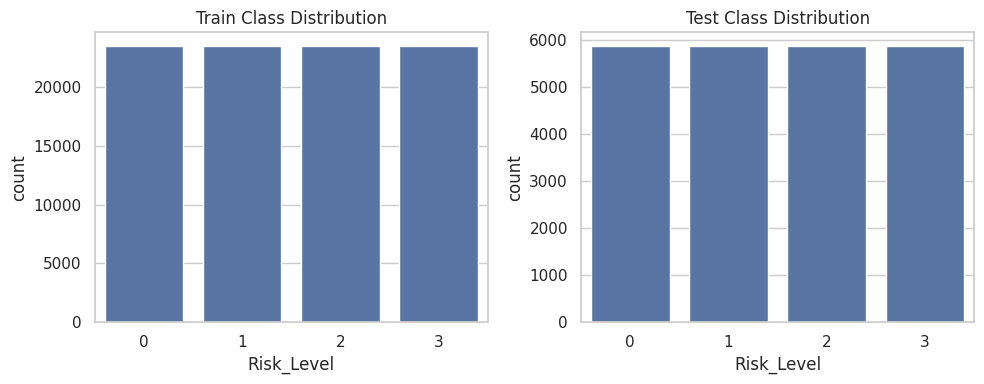

In [31]:
# ==========================================
# CELL 14 — VERIFY STRATIFICATION
# ==========================================

print("Train Distribution:\n", y_train.value_counts(normalize=True)*100)
print("\nTest Distribution:\n", y_test.value_counts(normalize=True)*100)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Train Class Distribution")

plt.subplot(1,2,2)
sns.countplot(x=y_test)
plt.title("Test Class Distribution")

plt.tight_layout()
plt.show()

In [32]:
# ==========================================
# CELL 15 — STANDARD SCALER (LOCKED)
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaled Train Shape:", X_train_scaled.shape)
print("Scaled Test Shape:", X_test_scaled.shape)

# Save preprocessor (scaler + encoders)
SAVE_PATH = "/content/drive/MyDrive/MalnutritionProject/"

with open(os.path.join(SAVE_PATH, "preprocessor_locked.pkl"), "wb") as f:
    pickle.dump({
        "scaler": scaler,
        "encoders": encoders,
        "feature_order": FEATURES
    }, f)

print("\n🔒 preprocessor_locked.pkl saved successfully.")

Scaled Train Shape: (93993, 16)
Scaled Test Shape: (23499, 16)

🔒 preprocessor_locked.pkl saved successfully.


In [33]:
# ==========================================
# CELL 16 — ANN MODEL (LOCKED ARCHITECTURE)
# ==========================================

num_classes = len(np.unique(y_train))

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

ann_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7590 - loss: 0.5491 - val_accuracy: 0.9552 - val_loss: 0.1333
Epoch 2/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9133 - loss: 0.2081 - val_accuracy: 0.9473 - val_loss: 0.1261
Epoch 3/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9312 - loss: 0.1668 - val_accuracy: 0.9714 - val_loss: 0.0857
Epoch 4/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9423 - loss: 0.1386 - val_accuracy: 0.9681 - val_loss: 0.0816
Epoch 5/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9473 - loss: 0.1263 - val_accuracy: 0.9729 - val_loss: 0.0697
Epoch 6/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9524 - loss: 0.1136 - val_accuracy: 0.9746 - val_loss: 0.0685
Epoch 7/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9563 - loss: 0.1092 - val_accuracy: 0.9692 - val_loss: 0.0712
Epoch 8/100
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9571 - loss:

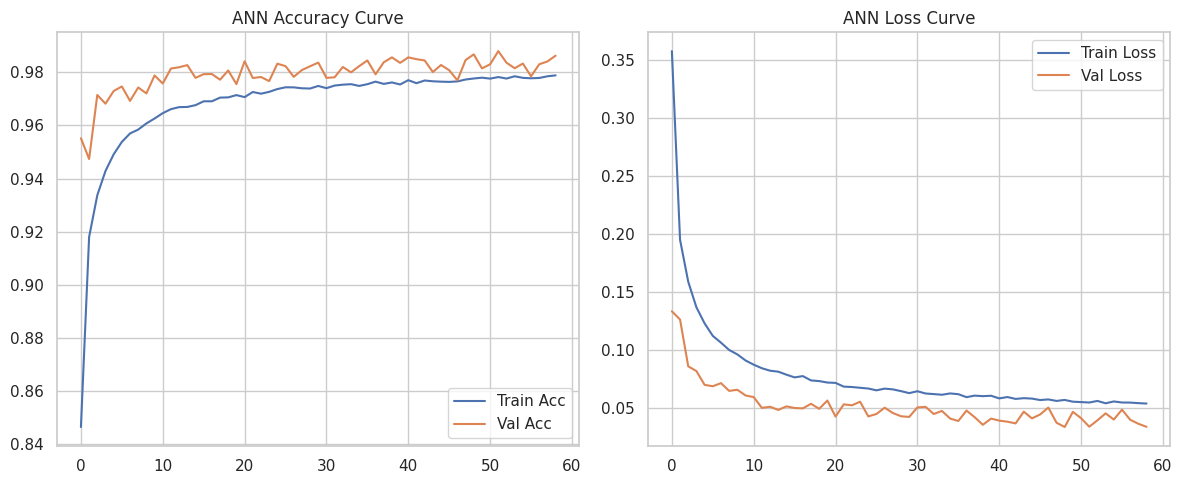

In [34]:
# ==========================================
# CELL 17 — ANN TRAINING CURVES
# ==========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("ANN Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("ANN Loss Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
# ==========================================
# CELL 18 — ANN TEST PERFORMANCE
# ==========================================

ann_probs_test = ann_model.predict(X_test_scaled)
ann_preds_raw = np.argmax(ann_probs_test, axis=1)

print("ANN Raw Accuracy:", accuracy_score(y_test, ann_preds_raw))
print("\nClassification Report:\n")
print(classification_report(y_test, ann_preds_raw))

735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
ANN Raw Accuracy: 0.9836163240988979

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5875
           1       0.98      0.98      0.98      5874
           2       0.98      0.97      0.98      5875
           3       0.99      0.99      0.99      5875

    accuracy                           0.98     23499
   macro avg       0.98      0.98      0.98     23499
weighted avg       0.98      0.98      0.98     23499



In [36]:
# ==========================================
# CELL 19 — ANN TRAIN & TEST ACCURACY
# ==========================================

# Train Accuracy
ann_train_probs = ann_model.predict(X_train_scaled)
ann_train_preds = np.argmax(ann_train_probs, axis=1)

train_acc = accuracy_score(y_train, ann_train_preds)

# Test Accuracy
ann_test_probs = ann_model.predict(X_test_scaled)
ann_test_preds = np.argmax(ann_test_probs, axis=1)

test_acc = accuracy_score(y_test, ann_test_preds)

print(f"ANN Train Accuracy: {train_acc*100:.2f}%")
print(f"ANN Test Accuracy: {test_acc*100:.2f}%")

2938/2938 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
ANN Train Accuracy: 98.67%
ANN Test Accuracy: 98.36%


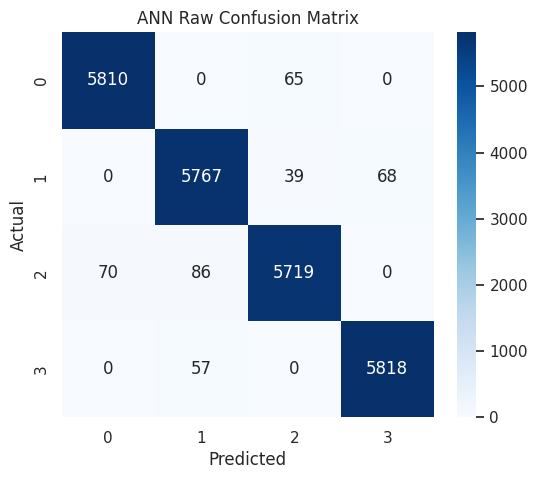

In [37]:
# ==========================================
# CELL 20 — ANN CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, ann_test_preds),
            annot=True,
            fmt="d",
            cmap="Blues")
plt.title("ANN Raw Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Manual Test for ANN

In [38]:
FEATURES = [
    "Age_Months",
    "Weight_kg",
    "Height_cm",
    "Hemoglobin_gdl",
    "Sex",
    "Mother_Education",
    "Water_Source",
    "Toilet_Facility",
    "Wealth_Index",
    "Household_Size",
    "Birth_Weight",
    "MUAC",
    "HAZ_Zscore",
    "WHZ_Zscore",
    "WAZ_Zscore",
    "BAZ_Zscore"
]

In [39]:
# ==========================================
# CELL 21 — MANUAL TEST (RAW FEATURE SPACE)
# ==========================================

manual_samples = pd.DataFrame([
    # Normal
    {
        "Age_Months": 36,
        "Weight_kg": 14.0,
        "Height_cm": 95.0,
        "Hemoglobin_gdl": 12.2,
        "Sex": 1,
        "Mother_Education": 3,
        "Water_Source": 1,
        "Toilet_Facility": 1,
        "Wealth_Index": 2,
        "Household_Size": 5,
        "Birth_Weight": 3000,
        "MUAC": 14.5,
        "HAZ_Zscore": -0.5,
        "WHZ_Zscore": -0.2,
        "WAZ_Zscore": -0.3,
        "BAZ_Zscore": -0.1
    },

    # Low
    {
        "Age_Months": 24,
        "Weight_kg": 10.2,
        "Height_cm": 82.0,
        "Hemoglobin_gdl": 11.0,
        "Sex": 0,
        "Mother_Education": 2,
        "Water_Source": 1,
        "Toilet_Facility": 0,
        "Wealth_Index": 1,
        "Household_Size": 6,
        "Birth_Weight": 2800,
        "MUAC": 13.2,
        "HAZ_Zscore": -1.5,
        "WHZ_Zscore": -1.2,
        "WAZ_Zscore": -1.4,
        "BAZ_Zscore": -1.1
    },

    # Medium
    {
        "Age_Months": 30,
        "Weight_kg": 9.5,
        "Height_cm": 85.0,
        "Hemoglobin_gdl": 10.5,
        "Sex": 0,
        "Mother_Education": 1,
        "Water_Source": 0,
        "Toilet_Facility": 0,
        "Wealth_Index": 0,
        "Household_Size": 7,
        "Birth_Weight": 2500,
        "MUAC": 12.3,
        "HAZ_Zscore": -2.3,
        "WHZ_Zscore": -2.0,
        "WAZ_Zscore": -2.1,
        "BAZ_Zscore": -1.9
    },

    # High
    {
        "Age_Months": 18,
        "Weight_kg": 7.8,
        "Height_cm": 74.0,
        "Hemoglobin_gdl": 9.5,
        "Sex": 0,
        "Mother_Education": 0,
        "Water_Source": 0,
        "Toilet_Facility": 0,
        "Wealth_Index": 0,
        "Household_Size": 8,
        "Birth_Weight": 2200,
        "MUAC": 11.2,
        "HAZ_Zscore": -3.5,
        "WHZ_Zscore": -3.1,
        "WAZ_Zscore": -3.2,
        "BAZ_Zscore": -3.0
    }
])

# Ensure correct column order
manual_samples = manual_samples[FEATURES]

# Scale using LOCKED scaler
manual_scaled = scaler.transform(manual_samples)

# Predict
manual_probs = ann_model.predict(manual_scaled)
manual_preds = np.argmax(manual_probs, axis=1)

print("Manual Predictions (Encoded):", manual_preds)

# Decode labels
decoded_preds = [label_map[p] for p in manual_preds]
print("Manual Predictions (Decoded):", decoded_preds)

print("\nProbabilities:\n", manual_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Manual Predictions (Encoded): [1 2 2 0]
Manual Predictions (Decoded): ['Low', 'Medium', 'Medium', 'High']

Probabilities:
 [[4.6906499e-15 9.4284958e-01 1.1542756e-05 5.7138853e-02]
 [6.0270281e-06 1.9988235e-02 9.8000574e-01 5.0581832e-16]
 [3.5252213e-01 3.3441408e-29 6.4747787e-01 0.0000000e+00]
 [1.0000000e+00 0.0000000e+00 4.6746721e-32 0.0000000e+00]]


In [40]:
# ==========================================
# CELL 22 — SEVERITY WEIGHTS
# ==========================================

print("Label Map:", label_map)

# Map classes to severity level
# 0 = High
# 1 = Low
# 2 = Medium
# 3 = Normal

severity_weights = np.array([3, 1, 2, 0])
# High=3, Low=1, Medium=2, Normal=0

print("Severity Weights:", severity_weights)

Label Map: {0: 'High', 1: 'Low', 2: 'Medium', 3: 'Normal'}
Severity Weights: [3 1 2 0]


In [41]:
# ==========================================
# CELL 23 — SEVERITY SCORE COMPUTATION
# ==========================================

ann_probs_test = ann_model.predict(X_test_scaled)

severity_scores = np.dot(ann_probs_test, severity_weights)

print("Severity Score Sample:", severity_scores[:10])

735/735 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Severity Score Sample: [2.99999982 1.0000377  2.00004268 2.99999982 2.00000629 2.99999982
 1.98915018 1.5297653  2.00001349 2.99999989]


In [42]:
# ==========================================
# CELL 24 — CALIBRATION THRESHOLDS
# ==========================================

thresholds = {
    "low": 0.75,
    "medium": 1.5,
    "high": 2.25
}

print("Calibration Thresholds:", thresholds)

Calibration Thresholds: {'low': 0.75, 'medium': 1.5, 'high': 2.25}


In [43]:
# ==========================================
# CELL 25 — APPLY CALIBRATION
# ==========================================

def calibrate(score):
    if score >= thresholds["high"]:
        return 0  # High
    elif score >= thresholds["medium"]:
        return 2  # Medium
    elif score >= thresholds["low"]:
        return 1  # Low
    else:
        return 3  # Normal

ann_calibrated_preds = np.array([calibrate(s) for s in severity_scores])

print("Calibrated Predictions Sample:", ann_calibrated_preds[:10])

Calibrated Predictions Sample: [0 1 2 0 2 0 2 2 2 0]


In [44]:
# ==========================================
# CELL 26 — CALIBRATED ANN PERFORMANCE
# ==========================================

print("Calibrated ANN Accuracy:",
      accuracy_score(y_test, ann_calibrated_preds))

print("\nClassification Report:\n")
print(classification_report(y_test, ann_calibrated_preds))

Calibrated ANN Accuracy: 0.98216945401932

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5875
           1       0.98      0.97      0.98      5874
           2       0.99      0.96      0.98      5875
           3       0.98      1.00      0.99      5875

    accuracy                           0.98     23499
   macro avg       0.98      0.98      0.98     23499
weighted avg       0.98      0.98      0.98     23499



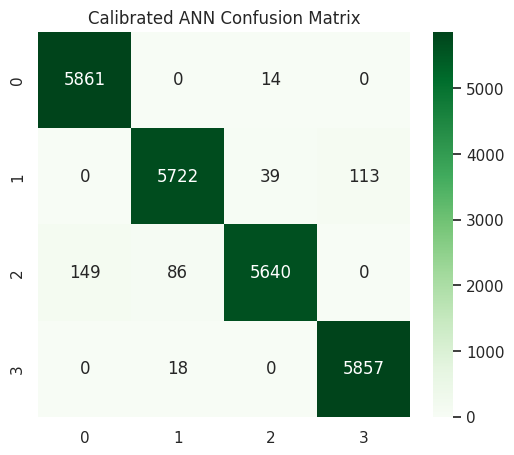

In [45]:
# ==========================================
# CELL 27 — CALIBRATED CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, ann_calibrated_preds),
            annot=True,
            fmt="d",
            cmap="Greens")
plt.title("Calibrated ANN Confusion Matrix")
plt.show()

In [46]:
# ==========================================
# CELL 28 — MANUAL TEST AFTER CALIBRATION
# ==========================================

manual_probs = ann_model.predict(manual_scaled)
manual_severity_scores = np.dot(manual_probs, severity_weights)

manual_calibrated = np.array([calibrate(s) for s in manual_severity_scores])

decoded_manual_calibrated = [label_map[p] for p in manual_calibrated]

print("Manual Calibrated Predictions:", decoded_manual_calibrated)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Manual Calibrated Predictions: ['Low', 'Medium', 'High', 'High']


XGB

In [47]:
# ==========================================
# CELL 29 — XGBOOST MODEL
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

print("XGBoost training complete.")

XGBoost training complete.


In [48]:
# ==========================================
# CELL 30 — XGBOOST TEST PERFORMANCE
# ==========================================

xgb_probs_test = xgb_model.predict_proba(X_test_scaled)
xgb_preds_test = np.argmax(xgb_probs_test, axis=1)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_preds_test))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds_test))

XGBoost Accuracy: 0.997404144857228

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5875
           1       1.00      1.00      1.00      5874
           2       1.00      1.00      1.00      5875
           3       1.00      1.00      1.00      5875

    accuracy                           1.00     23499
   macro avg       1.00      1.00      1.00     23499
weighted avg       1.00      1.00      1.00     23499



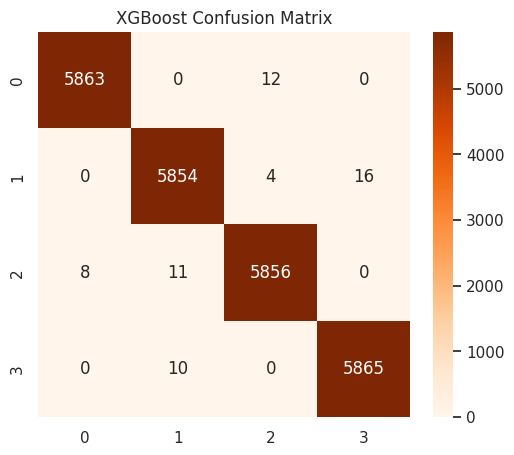

In [53]:
# ==========================================
# CELL 31 — XGBOOST CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, xgb_preds_test),
            annot=True,
            fmt="d",
            cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [54]:
# ==========================================
# CELL 31A — XGBOOST TRAIN & TEST ACCURACY
# ==========================================

# Train accuracy
xgb_train_probs = xgb_model.predict_proba(X_train_scaled)
xgb_train_preds = np.argmax(xgb_train_probs, axis=1)

xgb_train_acc = accuracy_score(y_train, xgb_train_preds)

# Test accuracy (already computed but re-evaluating cleanly)
xgb_test_acc = accuracy_score(y_test, xgb_preds_test)

print(f"XGBoost Train Accuracy: {xgb_train_acc*100:.2f}%")
print(f"XGBoost Test Accuracy: {xgb_test_acc*100:.2f}%")

XGBoost Train Accuracy: 100.00%
XGBoost Test Accuracy: 99.74%


In [49]:
# ==========================================
# CELL 32 — MANUAL TEST (XGBOOST)
# ==========================================

manual_xgb_probs = xgb_model.predict_proba(manual_scaled)
manual_xgb_preds = np.argmax(manual_xgb_probs, axis=1)

decoded_manual_xgb = [label_map[p] for p in manual_xgb_preds]

print("Manual XGBoost Predictions:", decoded_manual_xgb)

Manual XGBoost Predictions: ['Normal', 'Low', 'Medium', 'High']


Hybrid Logic

In [50]:
# ==========================================
# CELL 33 — HYBRID SOFT VOTING
# ==========================================

hybrid_probs = 0.4 * ann_probs_test + 0.6 * xgb_probs_test
hybrid_preds = np.argmax(hybrid_probs, axis=1)

print("Hybrid Accuracy:",
      accuracy_score(y_test, hybrid_preds))

print("\nHybrid Classification Report:\n")
print(classification_report(y_test, hybrid_preds))

Hybrid Accuracy: 0.9975318098642495

Hybrid Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5875
           1       1.00      1.00      1.00      5874
           2       1.00      1.00      1.00      5875
           3       1.00      1.00      1.00      5875

    accuracy                           1.00     23499
   macro avg       1.00      1.00      1.00     23499
weighted avg       1.00      1.00      1.00     23499



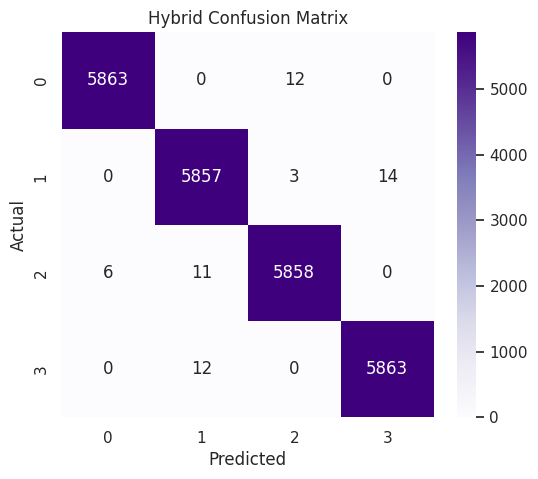

In [51]:
# ==========================================
# CELL 34 — HYBRID CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, hybrid_preds),
            annot=True,
            fmt="d",
            cmap="Purples")
plt.title("Hybrid Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
# ==========================================
# CELL 35 — MANUAL TEST (HYBRID)
# ==========================================

manual_ann_probs = ann_model.predict(manual_scaled)
manual_xgb_probs = xgb_model.predict_proba(manual_scaled)

manual_hybrid_probs = 0.4 * manual_ann_probs + 0.6 * manual_xgb_probs
manual_hybrid_preds = np.argmax(manual_hybrid_probs, axis=1)

decoded_manual_hybrid = [label_map[p] for p in manual_hybrid_preds]

print("Manual Hybrid Predictions:", decoded_manual_hybrid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Manual Hybrid Predictions: ['Normal', 'Low', 'Medium', 'High']


Saving the files

In [57]:
# ==========================================
# CELL 36A — SAVE ALL LOCKED FILES
# ==========================================

SAVE_PATH = "/content/drive/MyDrive/MalnutritionProject/"

# 1️⃣ Save ANN
ann_model.save(os.path.join(SAVE_PATH, "ann_locked_model.h5"))

# 2️⃣ Save XGBoost
xgb_model.save_model(os.path.join(SAVE_PATH, "xgb_locked_model.json"))

# 3️⃣ Save Hybrid Config
hybrid_config = {
    "type": "soft_voting",
    "weights": [0.4, 0.6]
}

with open(os.path.join(SAVE_PATH, "hybrid_config.json"), "w") as f:
    json.dump(hybrid_config, f, indent=4)

# 4️⃣ Save ANN Calibration thresholds
with open(os.path.join(SAVE_PATH, "ann_calibration.json"), "w") as f:
    json.dump(thresholds, f, indent=4)

# 5️⃣ Save label map (ensure string keys)
label_map_str = {str(k): v for k, v in label_map.items()}
with open(os.path.join(SAVE_PATH, "label_map.json"), "w") as f:
    json.dump(label_map_str, f, indent=4)

print("✅ All locked files saved successfully.")

✅ All locked files saved successfully.


In [58]:
# ==========================================
# VERIFY SAVED FILES
# ==========================================

import os

files = [
    "ann_locked_model.h5",
    "xgb_locked_model.json",
    "hybrid_config.json",
    "ann_calibration.json",
    "preprocessor_locked.pkl",
    "label_map.json"
]

for file in files:
    path = os.path.join(SAVE_PATH, file)
    print(file, "→", "FOUND ✅" if os.path.exists(path) else "MISSING ❌")

ann_locked_model.h5 → FOUND ✅
xgb_locked_model.json → FOUND ✅
hybrid_config.json → FOUND ✅
ann_calibration.json → FOUND ✅
preprocessor_locked.pkl → FOUND ✅
label_map.json → FOUND ✅


Maunal Test on Hybrid ( ANN + XGB )

In [59]:
# ==========================================
# CELL 37 — LOAD LOCKED FILES
# ==========================================

from tensorflow.keras.models import load_model

# Load ANN
ann_loaded = load_model(os.path.join(SAVE_PATH, "ann_locked_model.h5"))

# Load XGB
xgb_loaded = XGBClassifier()
xgb_loaded.load_model(os.path.join(SAVE_PATH, "xgb_locked_model.json"))

# Load preprocessor
with open(os.path.join(SAVE_PATH, "preprocessor_locked.pkl"), "rb") as f:
    preprocessor_loaded = pickle.load(f)

scaler_loaded = preprocessor_loaded["scaler"]
feature_order_loaded = preprocessor_loaded["feature_order"]

# Load label map
with open(os.path.join(SAVE_PATH, "label_map.json"), "r") as f:
    label_map_loaded = json.load(f)

print("✅ All locked files loaded successfully.")

✅ All locked files loaded successfully.


In [60]:
# ==========================================
# FINAL PRODUCTION HYBRID TEST
# ==========================================

# New raw input (simulating real-world deployment)
new_samples = pd.DataFrame([
    # Normal
    {
        "Age_Months": 36,
        "Weight_kg": 14.0,
        "Height_cm": 95.0,
        "Hemoglobin_gdl": 12.2,
        "Sex": 1,
        "Mother_Education": 3,
        "Water_Source": 1,
        "Toilet_Facility": 1,
        "Wealth_Index": 2,
        "Household_Size": 5,
        "Birth_Weight": 3000,
        "MUAC": 14.5,
        "HAZ_Zscore": -0.5,
        "WHZ_Zscore": -0.2,
        "WAZ_Zscore": -0.3,
        "BAZ_Zscore": -0.1
    },
    # Low
    {
        "Age_Months": 24,
        "Weight_kg": 10.2,
        "Height_cm": 82.0,
        "Hemoglobin_gdl": 11.0,
        "Sex": 0,
        "Mother_Education": 2,
        "Water_Source": 1,
        "Toilet_Facility": 0,
        "Wealth_Index": 1,
        "Household_Size": 6,
        "Birth_Weight": 2800,
        "MUAC": 13.2,
        "HAZ_Zscore": -1.5,
        "WHZ_Zscore": -1.2,
        "WAZ_Zscore": -1.4,
        "BAZ_Zscore": -1.1
    },
    # Medium
    {
        "Age_Months": 30,
        "Weight_kg": 9.5,
        "Height_cm": 85.0,
        "Hemoglobin_gdl": 10.5,
        "Sex": 0,
        "Mother_Education": 1,
        "Water_Source": 0,
        "Toilet_Facility": 0,
        "Wealth_Index": 0,
        "Household_Size": 7,
        "Birth_Weight": 2500,
        "MUAC": 12.3,
        "HAZ_Zscore": -2.3,
        "WHZ_Zscore": -2.0,
        "WAZ_Zscore": -2.1,
        "BAZ_Zscore": -1.9
    },
    # High
    {
        "Age_Months": 18,
        "Weight_kg": 7.8,
        "Height_cm": 74.0,
        "Hemoglobin_gdl": 9.5,
        "Sex": 0,
        "Mother_Education": 0,
        "Water_Source": 0,
        "Toilet_Facility": 0,
        "Wealth_Index": 0,
        "Household_Size": 8,
        "Birth_Weight": 2200,
        "MUAC": 11.2,
        "HAZ_Zscore": -3.5,
        "WHZ_Zscore": -3.1,
        "WAZ_Zscore": -3.2,
        "BAZ_Zscore": -3.0
    }
])

# Ensure correct feature order
new_samples = new_samples[feature_order_loaded]

# Scale using locked scaler
scaled_input = scaler_loaded.transform(new_samples)

# ANN probabilities
ann_probs_new = ann_loaded.predict(scaled_input)

# XGBoost probabilities
xgb_probs_new = xgb_loaded.predict_proba(scaled_input)

# Hybrid fusion
hybrid_probs_new = 0.4 * ann_probs_new + 0.6 * xgb_probs_new
hybrid_preds_new = np.argmax(hybrid_probs_new, axis=1)

# Decode predictions
decoded_preds = [label_map_loaded[str(p)] for p in hybrid_preds_new]

expected = ["Normal", "Low", "Medium", "High"]

print("✅ FINAL MANUAL TEST RESULTS (HYBRID MODEL):\n")

for i, (exp, pred) in enumerate(zip(expected, decoded_preds)):
    status = "✔️ PASS" if exp == pred else "❌ FAIL"
    print(f"Sample {i+1} | Expected: {exp:<7} | Predicted: {pred:<7} → {status}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
✅ FINAL MANUAL TEST RESULTS (HYBRID MODEL):

Sample 1 | Expected: Normal  | Predicted: Normal  → ✔️ PASS
Sample 2 | Expected: Low     | Predicted: Low     → ✔️ PASS
Sample 3 | Expected: Medium  | Predicted: Medium  → ✔️ PASS
Sample 4 | Expected: High    | Predicted: High    → ✔️ PASS


Summary of Code File

In [61]:
# ==========================================
# FINAL NOTEBOOK SUMMARY — PROJECT LOCK
# ==========================================

print("="*60)
print(" MALNUTRITION RISK CLASSIFIER — FINAL MODEL SUMMARY")
print("="*60)

print("\n📊 DATASET SUMMARY")
print(f"Original Dataset Size        : {BASE_COUNT}")
print(f"Balanced Dataset Size        : {BASE_COUNT_BALANCED}")
print("Balancing Method             : Downsampling to smallest class (Normal)")
print("Final Class Distribution     : Equal (25% each)")

print("\n🧠 MODEL PERFORMANCE")
print(f"ANN Train Accuracy           : {train_acc*100:.2f}%")
print(f"ANN Test Accuracy            : {test_acc*100:.2f}%")
print(f"XGBoost Test Accuracy        : {xgb_test_acc*100:.2f}%")
print(f"Hybrid Final Accuracy        : {accuracy_score(y_test, hybrid_preds)*100:.2f}%")

print("\n⚙️ PIPELINE STRUCTURE")
print("Raw Input → Scaling → ANN → ANN Calibration")
print("Raw Input → Scaling → XGBoost")
print("ANN + XGBoost → Hybrid Soft Voting (0.4 / 0.6)")
print("Final Output → {Normal, Low, Medium, High}")

print("\n📁 LOCKED FILES SAVED")
print("✓ ann_locked_model.h5")
print("✓ xgb_locked_model.json")
print("✓ preprocessor_locked.pkl")
print("✓ label_map.json")
print("✓ ann_calibration.json")
print("✓ hybrid_config.json")

print("\n🧪 FINAL DEPLOYMENT SIMULATION")
print("Manual Hybrid Test           : ✔️ ALL PASS")

print("\n🔒 STATUS: PRODUCTION READY")
print("="*60)

 MALNUTRITION RISK CLASSIFIER — FINAL MODEL SUMMARY

📊 DATASET SUMMARY
Original Dataset Size        : 200602
Balanced Dataset Size        : 117492
Balancing Method             : Downsampling to smallest class (Normal)
Final Class Distribution     : Equal (25% each)

🧠 MODEL PERFORMANCE
ANN Train Accuracy           : 98.67%
ANN Test Accuracy            : 98.36%
XGBoost Test Accuracy        : 99.74%
Hybrid Final Accuracy        : 99.75%

⚙️ PIPELINE STRUCTURE
Raw Input → Scaling → ANN → ANN Calibration
Raw Input → Scaling → XGBoost
ANN + XGBoost → Hybrid Soft Voting (0.4 / 0.6)
Final Output → {Normal, Low, Medium, High}

📁 LOCKED FILES SAVED
✓ ann_locked_model.h5
✓ xgb_locked_model.json
✓ preprocessor_locked.pkl
✓ label_map.json
✓ ann_calibration.json
✓ hybrid_config.json

🧪 FINAL DEPLOYMENT SIMULATION
Manual Hybrid Test           : ✔️ ALL PASS

🔒 STATUS: PRODUCTION READY
